# 1D

CORE SIM+ Lite — 1D Two-Group Diffusion

[1] Building system matrices ...

[2] Static forward k-eigenvalue solve ...
  Converged in 102 iterations,  k_eff = 1.00340561

[3] Adjoint k-eigenvalue solve ...
  Converged in 102 iterations,  k_eff = 1.00340561

[4] Frequency-domain noise solve ...
   f =   0.1 Hz  |  |dP/P| = 9.2040e-03  |  phase = -7.6 deg
   f =   1.0 Hz  |  |dP/P| = 9.1192e-03  |  phase = -3.6 deg
   f =   5.0 Hz  |  |dP/P| = 8.8500e-03  |  phase = -14.4 deg
   f =  10.0 Hz  |  |dP/P| = 8.1425e-03  |  phase = -27.0 deg
   f =  20.0 Hz  |  |dP/P| = 6.4093e-03  |  phase = -45.4 deg

[5] Plotting ...


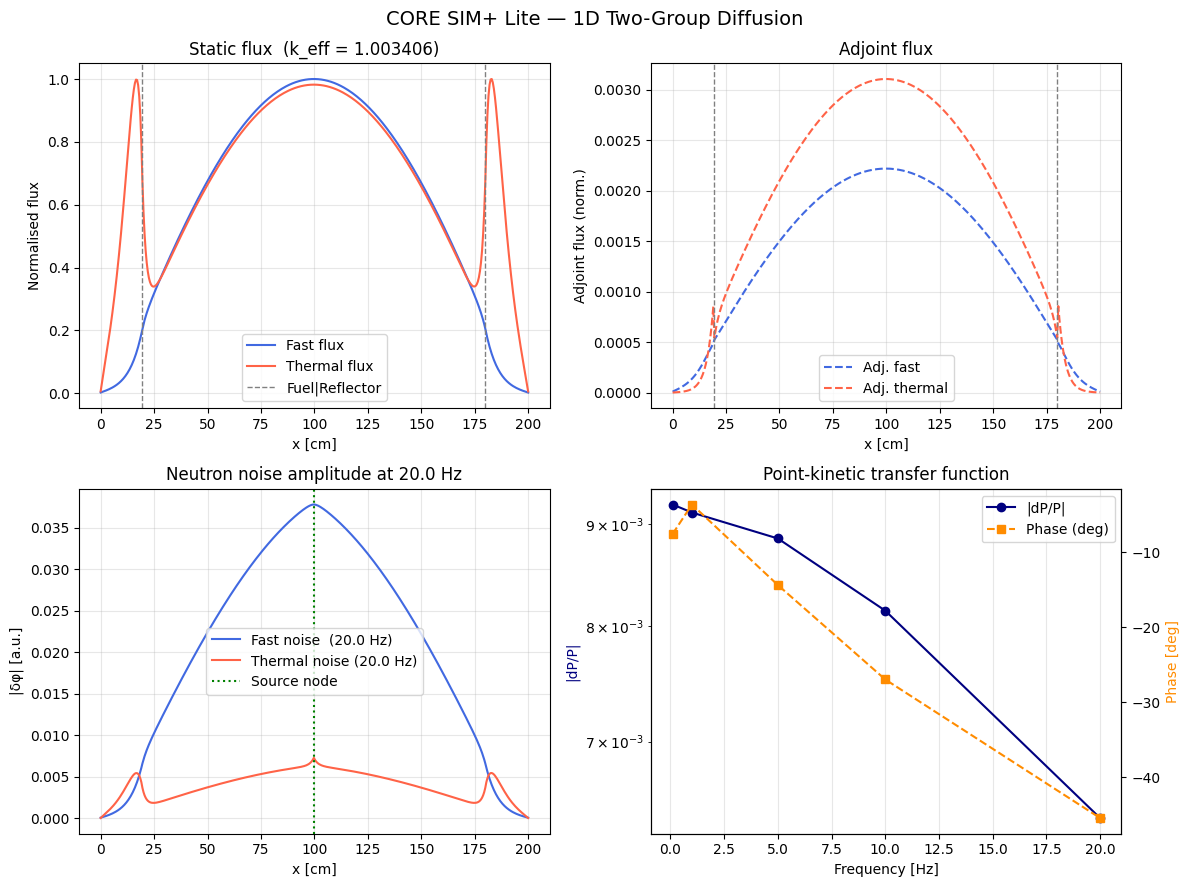

In [3]:
# -*- coding: utf-8 -*-
"""
CORE SIM+ Lite — 1D Two-Group Neutron Diffusion Solver
=======================================================
Solves:
  1. Static k-eigenvalue problem (forward + adjoint)
  2. Frequency-domain neutron noise problem

Reference:
  Mylonakis, Vinai, Demazière — Annals of Nuclear Energy 155 (2021) 108149

"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve

# ============================================================
# GEOMETRY
# ============================================================
# Layout:  reflector | fuel core | reflector
#          20 cm     |  160 cm   |  20 cm       total = 200 cm
#
# This mirrors a typical PWR slab benchmark geometry.

L     = 200.0        # total length [cm]
N     = 400          # number of nodes
dx    = L / (N - 1)
x     = np.linspace(0, L, N)

n_total = 2 * N      # fast + thermal unknowns

# Fuel region: nodes inside [20 cm, 180 cm]
fuel_lo = int(20.0  / dx)   # ~40
fuel_hi = int(180.0 / dx)   # ~360

# ============================================================
# MATERIAL MODEL
# ============================================================
# Two-group cross-sections based on the IAEA 2-D PWR benchmark
# (collapsed to 2 groups from standard libraries).
# Units: D [cm],  cross-sections [cm^-1]
#
# k_inf (fuel) ≈ 1.02  → with leakage, k_eff ≈ 1.00 for this geometry.

def get_material(i):
    if fuel_lo <= i <= fuel_hi:
        # UO2 fuel assembly (homogenised)
        return dict(D1=1.44,   D2=0.37,
                    Sa1=0.006,  Sa2=0.096,
                    S12=0.016,
                    nuf1=0.0,   nuf2=0.135)
    else:
        # Water reflector
        return dict(D1=1.50,   D2=0.20,
                    Sa1=0.0003, Sa2=0.020,
                    S12=0.040,
                    nuf1=0.0,   nuf2=0.0)

# ============================================================
# INDEX HELPERS
# ============================================================

def fast(i):    return i        # fast-group index in [0, N)
def thermal(i): return N + i   # thermal-group index in [N, 2N)

# ============================================================
# MARSHAK (VACUUM) BOUNDARY CONDITION
#
# Extrapolation length: z_ext = 2/3 * D  (one-speed approximation)
# The Marshak condition modifies the diagonal of the boundary node:
#
#   D * (phi_b - 0) / (dx/2 + z_ext) = flux at boundary
#
# We implement it as a Robin condition on the diffusion stencil:
#
#   For the left boundary node (i=0):
#       coefficient: D/dx^2 + D/(dx * z_ext)  [instead of 2D/dx^2]
#   For the right boundary node (i=N-1): symmetric.
#
# This is equivalent to the Marshak condition used in CORE SIM+.
# ============================================================

def build_system():
    """Build the loss matrix A and fission matrix F for the static problem."""

    A    = lil_matrix((n_total, n_total))
    Fmat = lil_matrix((n_total, n_total))

    for i in range(N):
        m = get_material(i)
        D1   = m["D1"];  D2   = m["D2"]
        Sa1  = m["Sa1"]; Sa2  = m["Sa2"]
        S12  = m["S12"]
        nuf1 = m["nuf1"]; nuf2 = m["nuf2"]

        fi = fast(i)
        ti = thermal(i)

        # ── Marshak (vacuum) boundary nodes ─────────────────────────
        if i == 0 or i == N - 1:
            # Extrapolation lengths for each group
            z1 = (2.0 / 3.0) * D1
            z2 = (2.0 / 3.0) * D2

            # Effective one-sided diffusion coefficient
            # (one neighbour only → half-cell + extrapolation length)
            a1 = D1 / dx**2 + D1 / (dx * z1)
            a2 = D2 / dx**2 + D2 / (dx * z2)

            # Diagonal: leakage + absorption + scattering-out
            A[fi, fi] = a1 + Sa1 + S12
            A[ti, ti] = a2 + Sa2

            # Off-diagonal: coupling to the single interior neighbour
            nb = 1 if i == 0 else N - 2   # neighbour index
            A[fi, fast(nb)]    = -D1 / dx**2
            A[ti, thermal(nb)] = -D2 / dx**2

            # Scattering fast → thermal
            A[ti, fi] = -S12

            # Fission
            Fmat[fi, fi] += nuf1
            Fmat[fi, ti] += nuf2
            continue

        # ── Interior nodes ───────────────────────────────────────────

        # Fast group
        A[fi, fast(i-1)] = -D1 / dx**2
        A[fi, fi        ] =  2*D1/dx**2 + Sa1 + S12
        A[fi, fast(i+1) ] = -D1 / dx**2

        # Thermal group
        A[ti, thermal(i-1)] = -D2 / dx**2
        A[ti, ti            ] =  2*D2/dx**2 + Sa2
        A[ti, thermal(i+1)  ] = -D2 / dx**2

        # Scattering: fast → thermal  (source term in thermal eq.)
        A[ti, fi] = -S12

        # Fission matrix (contributes to fast group source)
        Fmat[fi, fi] += nuf1
        Fmat[fi, ti] += nuf2

    return csr_matrix(A), csr_matrix(Fmat)


# ============================================================
# POWER ITERATION  (forward or adjoint)
# ============================================================

def power_iteration(A, F, adjoint=False, tol=1e-9, max_iter=500):
    """
    Solve  A Φ = (1/k) F Φ  by power iteration.

    At each iteration:
        1. phi_new = A^{-1} [ (1/k) F phi ]
        2. k_new   = k * ||F phi_new|| / ||F phi||

    For the adjoint problem pass adjoint=True:
        A^T Φ† = (1/k) F^T Φ†

    Returns
    -------
    phi : ndarray, shape (n_total,)
    k   : float
    """
    if adjoint:
        A = A.T.tocsr()
        F = F.T.tocsr()

    phi    = np.ones(n_total)
    phi   /= np.linalg.norm(phi)
    k      = 1.0

    for it in range(max_iter):
        Fphi    = F @ phi                        # fission source
        rhs     = Fphi / k                       # scaled RHS: (1/k) F phi
        phi_new = spsolve(A, rhs)                # A phi_new = (1/k) F phi

        # Standard power-iteration eigenvalue update:
        #   k_new = k * integral(F phi_new) / integral(F phi)
        Fphi_new = F @ phi_new
        k_new    = k * np.sum(Fphi_new) / np.sum(Fphi)

        phi_new /= np.linalg.norm(phi_new)

        err = abs(k_new - k) / abs(k_new)
        k   = k_new
        phi = phi_new

        if err < tol:
            print(f"  Converged in {it+1} iterations,  k_eff = {k:.8f}")
            break
    else:
        print(f"  Warning: did not converge in {max_iter} iterations, k = {k:.6f}")

    return phi, k


# ============================================================
# DYNAMIC (NOISE) MATRIX  A_noise(ω)
#
# From Appendix A of the paper:
#
#  A_noise = A_crit + delta_A(ω)
#
# where delta_A modifies the diagonal to account for:
#   - neutron speed terms  iω/v_g
#   - delayed neutron correction  (1 - iωβ/(iω+λ)) / k_eff
#
# The full Rcrit_dyn matrix replaces the static removal/fission
# terms in the diffusion operator with frequency-dependent ones.
# ============================================================

def build_noise_matrix(A_static, phi_fast, phi_thermal, k_eff,
                       omega,
                       beta=0.0065, lam=0.08,
                       v1=1.0e7, v2=2.2e5):
    """
    Build the complex loss matrix A_noise(ω) used to solve:

        A_noise(ω) · δΦ(ω) = S(ω)

    Parameters
    ----------
    A_static   : real sparse CSR matrix (2N × 2N), the static operator
    phi_fast   : (N,) static fast flux
    phi_thermal: (N,) static thermal flux
    k_eff      : float, effective multiplication factor
    omega      : float, angular frequency [rad/s]
    beta       : delayed neutron fraction (total)
    lam        : precursor decay constant [1/s]  (one-group delayed)
    v1, v2     : neutron speeds [cm/s] for fast and thermal groups

    Returns
    -------
    A_noise : complex CSR sparse matrix (2N × 2N)
    """
    # Start from a complex copy of the static matrix
    A_noise = A_static.astype(complex).tolil()

    # Delayed-neutron correction factor  (1 - iωβ/(iω+λ)) / k_eff
    # This modifies the effective fission cross-section in the dynamic eq.
    delayed_factor = (1.0 - 1j * omega * beta / (1j * omega + lam)) / k_eff

    for i in range(N):
        m    = get_material(i)
        nuf1 = m["nuf1"];  nuf2 = m["nuf2"]
        vRf1 = nuf1;       vRf2 = nuf2   # νΣf

        fi = fast(i)
        ti = thermal(i)

        # ── Speed term  iω/v_g  added to diagonal ───────────────────
        A_noise[fi, fi] += 1j * omega / v1
        A_noise[ti, ti] += 1j * omega / v2

        # ── Fission contribution to fast diagonal ────────────────────
        # In A_static the fission term is absent (it is in F).
        # In A_noise we subtract the frequency-adjusted fission term
        # so that: A_noise Φ = S  corresponds to (L - F_dyn) Φ = S
        A_noise[fi, fi] -= vRf1 * delayed_factor
        A_noise[fi, ti] -= vRf2 * delayed_factor

    return csr_matrix(A_noise)


# ============================================================
# NOISE SOURCE  (localised absorber of variable strength)
# ============================================================

def make_absorber_source(phi_fast, phi_thermal,
                         node, group,
                         delta_Sigma=1e-3):
    """
    Model a small fluctuation of absorption cross-section at `node`
    in `group` (1 = fast, 2 = thermal).

    S_g(r, ω) = δΣ_a,g(r, ω) · φ_g^0(r)     [from Eq. (4) of the paper]

    Returns
    -------
    S : complex ndarray, shape (2N,)
    """
    S = np.zeros(n_total, dtype=complex)

    if group == 1:
        S[fast(node)]    =  delta_Sigma * phi_fast[node]
        # Also drives thermal through scattering balance; omitted here
        # for the minimal source model
    elif group == 2:
        S[thermal(node)] =  delta_Sigma * phi_thermal[node]

    return S


# ============================================================
# POINT-KINETIC TRANSFER FUNCTION EXTRACTION
#
# From Eq. (17) of the paper:
#
#   dP(ω)/P₀ = ∫ [(1/v1)φ†1 δφ1 + (1/v2)φ†2 δφ2] dr
#              ──────────────────────────────────────────
#              ∫ [(1/v1)φ†1 φ1  + (1/v2)φ†2 φ2 ] dr
# ============================================================

def extract_point_kinetic(phi_adj_fast, phi_adj_thermal,
                          delta_phi_fast, delta_phi_thermal,
                          phi_fast, phi_thermal,
                          v1=1.0e7, v2=2.2e5):
    """
    Returns dP(ω)/P₀  (complex scalar).
    """
    numerator   = (np.sum(phi_adj_fast    * delta_phi_fast    / v1) +
                   np.sum(phi_adj_thermal * delta_phi_thermal / v2))

    denominator = (np.sum(phi_adj_fast    * phi_fast          / v1) +
                   np.sum(phi_adj_thermal * phi_thermal        / v2))

    return numerator / denominator


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":

    print("=" * 60)
    print("CORE SIM+ Lite — 1D Two-Group Diffusion")
    print("=" * 60)

    # ── Build matrices ───────────────────────────────────────────
    print("\n[1] Building system matrices ...")
    A, F = build_system()

    # ── Static forward solve ─────────────────────────────────────
    print("\n[2] Static forward k-eigenvalue solve ...")
    phi, k_eff = power_iteration(A, F, adjoint=False)

    phi_fast     = phi[:N].copy()
    phi_thermal  = phi[N:].copy()

    # Normalise to peak = 1
    phi_fast    /= np.max(np.abs(phi_fast))
    phi_thermal /= np.max(np.abs(phi_thermal))

    # ── Adjoint solve ────────────────────────────────────────────
    print("\n[3] Adjoint k-eigenvalue solve ...")
    phi_adj, k_adj = power_iteration(A, F, adjoint=True)

    phi_adj_fast     = phi_adj[:N].copy()
    phi_adj_thermal  = phi_adj[N:].copy()

    # Normalise adjoint so that <φ†, φ> = 1
    norm = (np.sum(phi_adj_fast * phi_fast) +
            np.sum(phi_adj_thermal * phi_thermal))
    phi_adj_fast    /= norm
    phi_adj_thermal /= norm

    # ── Frequency-domain noise solve ─────────────────────────────
    print("\n[4] Frequency-domain noise solve ...")

    # Noise source: thermal absorber fluctuation at fuel-region node
    noise_node  = (fuel_lo + fuel_hi) // 2   # centre of fuel region
    frequencies = [0.1, 1.0, 5.0, 10.0, 20.0]   # Hz

    dP_over_P = []

    for f_hz in frequencies:
        omega = 2 * np.pi * f_hz

        # Build complex noise matrix
        A_noise = build_noise_matrix(A, phi_fast, phi_thermal, k_eff, omega)

        # Build noise source  (thermal absorber perturbation)
        S = make_absorber_source(phi_fast, phi_thermal,
                                 node=noise_node, group=2)

        # Solve  A_noise · δΦ = S
        delta_phi = spsolve(A_noise, S)

        delta_phi_fast     = delta_phi[:N]
        delta_phi_thermal  = delta_phi[N:]

        # Point-kinetic amplitude
        dP = extract_point_kinetic(phi_adj_fast, phi_adj_thermal,
                                   delta_phi_fast, delta_phi_thermal,
                                   phi_fast, phi_thermal)
        dP_over_P.append(dP)
        print(f"   f = {f_hz:5.1f} Hz  |  |dP/P| = {abs(dP):.4e}"
              f"  |  phase = {np.angle(dP, deg=True):.1f} deg")

    # ── Visualisation ─────────────────────────────────────────────
    print("\n[5] Plotting ...")

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle("CORE SIM+ Lite — 1D Two-Group Diffusion", fontsize=14)

    # --- Static fluxes -------------------------------------------
    ax = axes[0, 0]
    ax.plot(x, phi_fast,    label="Fast flux",    color="royalblue")
    ax.plot(x, phi_thermal, label="Thermal flux", color="tomato")
    ax.axvline(x[fuel_lo], color="gray", ls="--", lw=1, label="Fuel|Reflector")
    ax.axvline(x[fuel_hi], color="gray", ls="--", lw=1)
    ax.set_xlabel("x [cm]");  ax.set_ylabel("Normalised flux")
    ax.set_title(f"Static flux  (k_eff = {k_eff:.6f})")
    ax.legend();  ax.grid(True, alpha=0.3)

    # --- Adjoint fluxes ------------------------------------------
    ax = axes[0, 1]
    ax.plot(x, phi_adj_fast,    label="Adj. fast",    color="royalblue", ls="--")
    ax.plot(x, phi_adj_thermal, label="Adj. thermal", color="tomato",    ls="--")
    ax.axvline(x[fuel_lo], color="gray", ls="--", lw=1)
    ax.axvline(x[fuel_hi], color="gray", ls="--", lw=1)
    ax.set_xlabel("x [cm]");  ax.set_ylabel("Adjoint flux (norm.)")
    ax.set_title("Adjoint flux")
    ax.legend();  ax.grid(True, alpha=0.3)

    # --- Noise amplitude at last frequency -----------------------
    omega_last = 2 * np.pi * frequencies[-1]
    A_noise_last = build_noise_matrix(A, phi_fast, phi_thermal, k_eff, omega_last)
    S_last       = make_absorber_source(phi_fast, phi_thermal,
                                        node=noise_node, group=2)
    delta_phi_last = spsolve(A_noise_last, S_last)

    ax = axes[1, 0]
    ax.plot(x, np.abs(delta_phi_last[:N]),
            label=f"Fast noise  ({frequencies[-1]} Hz)", color="royalblue")
    ax.plot(x, np.abs(delta_phi_last[N:]),
            label=f"Thermal noise ({frequencies[-1]} Hz)", color="tomato")
    ax.axvline(x[noise_node], color="green", ls=":", lw=1.5, label="Source node")
    ax.set_xlabel("x [cm]");  ax.set_ylabel("|δφ| [a.u.]")
    ax.set_title(f"Neutron noise amplitude at {frequencies[-1]} Hz")
    ax.legend();  ax.grid(True, alpha=0.3)

    # --- Point-kinetic transfer function -------------------------
    freqs = np.array(frequencies)
    amps  = np.abs(dP_over_P)
    phases = np.angle(dP_over_P, deg=True)

    ax = axes[1, 1]
    ax2 = ax.twinx()
    l1, = ax.semilogy(freqs, amps,   "o-", color="navy",  label="|dP/P|")
    l2, = ax2.plot(   freqs, phases, "s--", color="darkorange", label="Phase (deg)")
    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel("|dP/P|",       color="navy")
    ax2.set_ylabel("Phase [deg]", color="darkorange")
    ax.set_title("Point-kinetic transfer function")
    ax.legend(handles=[l1, l2], loc="upper right")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()